# Phase 0 — Corpus overview

Political-compass position and chunk distribution across the seven corpora.
All chunks are from `scored_chunks.jsonl`; retained subset (conf_margin ≥ 0.015) is in `retained.jsonl`.

In [2]:
import json
import random
from collections import defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import numpy as np
import pandas as pd
from scipy.stats import gaussian_kde

plt.rcParams.update({
    "font.family":       "serif",
    "font.size":         11,
    "axes.spines.top":   False,
    "axes.spines.right": False,
})

BASE      = Path("../data/experts/quadrant-pools")
SOURCES   = ["allsides", "ec_press", "ire_press", "uk_press", "hoc", "reddit_liberal", "reddit_conservative"]
QUADRANTS = ["right_auth", "left_auth", "left_lib", "right_lib"]

Q_LABEL = {
    "right_auth": "Q1 (right_auth)",
    "left_auth":  "Q2 (left_auth)",
    "left_lib":   "Q3 (left_lib)",
    "right_lib":  "Q4 (right_lib)",
}
Q_SHORT = {
    "right_auth": "Q1",
    "left_auth":  "Q2",
    "left_lib":   "Q3",
    "right_lib":  "Q4",
}
COLORS = {
    "right_auth": "#9dc5e2",
    "left_auth":  "#e17a7a",
    "left_lib":   "#aee8bf",
    "right_lib":  "#fbf09e",
}
SOURCE_LABEL = {
    "allsides":            "AllSides",
    "ec_press":            "EC Press Releases",
    "ire_press":           "Irish Gov. Press Releases",
    "uk_press":            "UK Gov. Press Releases",
    "hoc":                 "UK House of Commons",
    "reddit_liberal":      "Reddit (Liberal)",
    "reddit_conservative": "Reddit (Conservative)",
}
FAMILY = {
    "reddit_liberal":      "Reddit",
    "reddit_conservative": "Reddit",
    "allsides":            "Press",
    "ec_press":            "Press",
    "ire_press":           "Press",
    "uk_press":            "Press",
    "hoc":                 "Speeches",
}
FAMILY_STYLE = {
    "Reddit":   {"color": "#e6194b", "marker": "o", "alpha": 0.25, "zorder": 3},
    "Press":    {"color": "#3cb44b", "marker": "s", "alpha": 0.25, "zorder": 2},
    "Speeches": {"color": "#4363d8", "marker": "^", "alpha": 0.35, "zorder": 4},
}

## Mean ideological position per source × quadrant

Each bubble = one source × quadrant cell. Position = mean (econ, soc) score of all chunks; area ∝ chunk count.

In [3]:
records = []

for source in SOURCES:
    path = BASE / source / "scored_chunks.jsonl"
    buckets = defaultdict(lambda: {"econ": [], "soc": [], "abs_econ": [], "abs_soc": [], "conf": []})
    with open(path) as f:
        for line in f:
            d = json.loads(line)
            q = d["quadrant"]
            ae, as_ = d["score_abs_econ"], d["score_abs_soc"]
            if ae == ae:   buckets[q]["abs_econ"].append(ae)
            if as_ == as_: buckets[q]["abs_soc"].append(as_)
            e, s = d["score_econ"], d["score_soc"]
            if e == e: buckets[q]["econ"].append(e)
            if s == s: buckets[q]["soc"].append(s)
            c = d["confidence_margin"]
            if c == c: buckets[q]["conf"].append(c)

    total = sum(len(v["econ"]) for v in buckets.values())
    for q in QUADRANTS:
        b = buckets[q]
        n = len(b["econ"])
        records.append({
            "source":        source,
            "quadrant":      q,
            "n_chunks":      n,
            "pct_of_source": 100 * n / total if total else 0,
            "mean_econ":     float(np.mean(b["econ"]))     if b["econ"]     else float("nan"),
            "mean_soc":      float(np.mean(b["soc"]))      if b["soc"]      else float("nan"),
            "mean_conf":     float(np.mean(b["conf"]))     if b["conf"]     else float("nan"),
        })

df = pd.DataFrame(records)
print(df[["source", "quadrant", "n_chunks", "mean_econ", "mean_soc", "mean_conf"]]
      .to_string(index=False, float_format="{:.4f}".format))

             source   quadrant  n_chunks  mean_econ  mean_soc  mean_conf
           allsides right_auth      5353     0.0269    0.0108     0.0093
           allsides  left_auth       259    -0.0061    0.0142     0.0050
           allsides   left_lib       549    -0.0075   -0.0282     0.0067
           allsides  right_lib     12231     0.0286   -0.0195     0.0149
           ec_press right_auth      1604     0.0049    0.0130     0.0038
           ec_press  left_auth     27916    -0.0225    0.0140     0.0109
           ec_press   left_lib     39221    -0.0253   -0.0209     0.0152
           ec_press  right_lib      2524     0.0058   -0.0202     0.0050
          ire_press right_auth       635     0.0082    0.0132     0.0058
          ire_press  left_auth      1733    -0.0151    0.0116     0.0081
          ire_press   left_lib      6198    -0.0202   -0.0252     0.0158
          ire_press  right_lib      1481     0.0106   -0.0220     0.0089
           uk_press right_auth     22231     0.0111

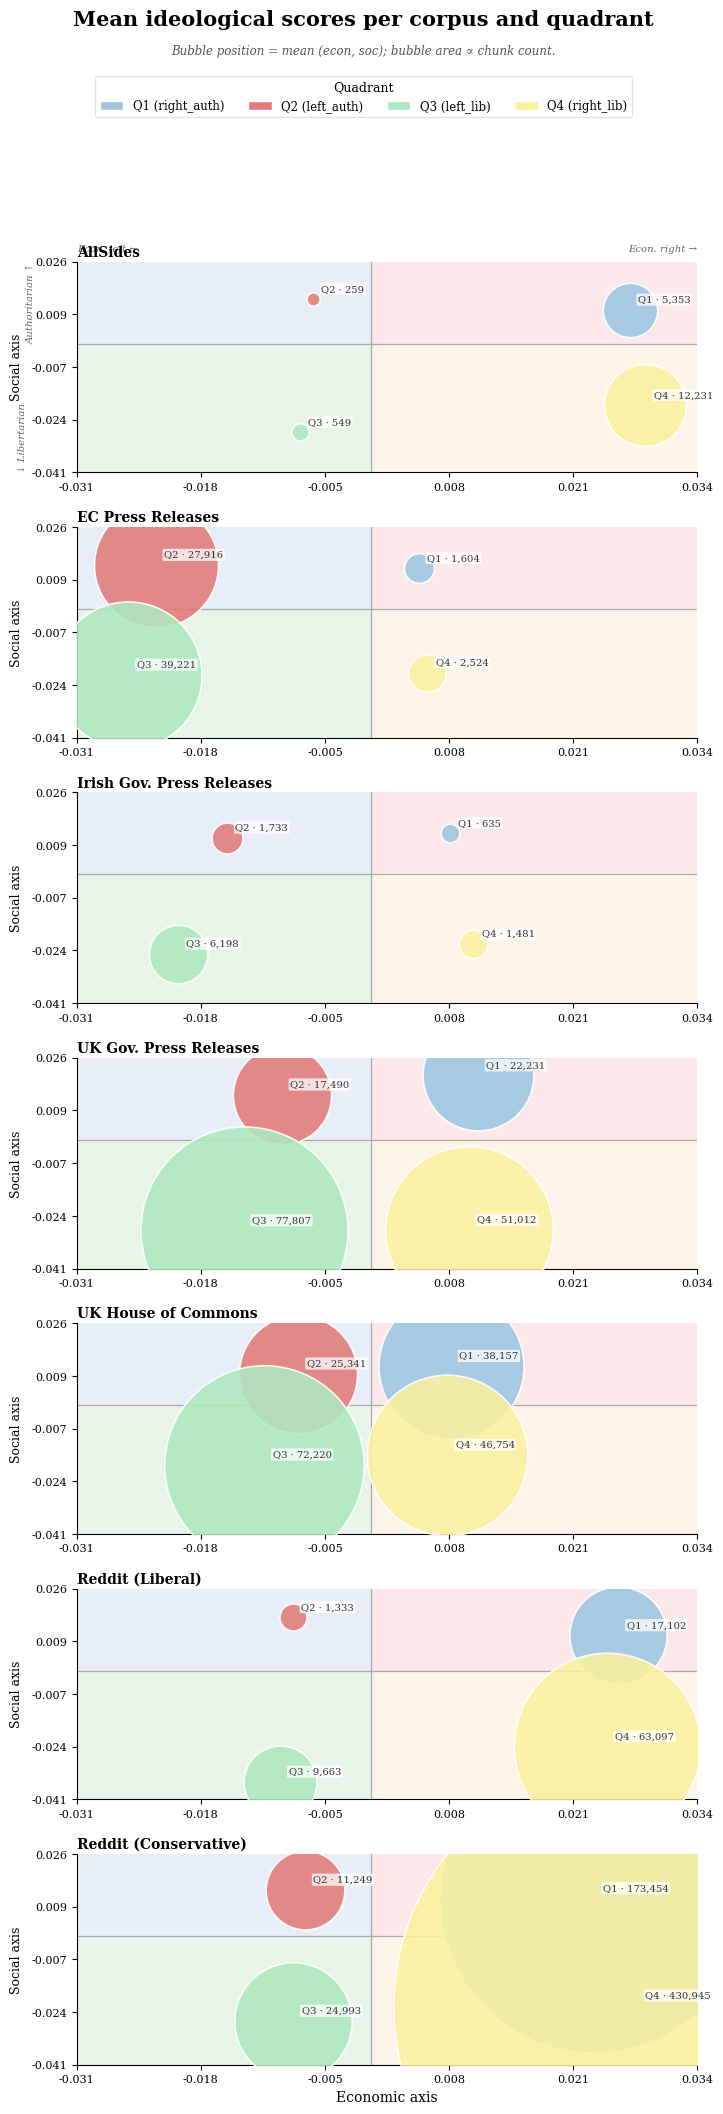

In [4]:
x_all = df["mean_econ"].to_numpy()
y_all = df["mean_soc"].to_numpy()
x_pad = max((x_all.max() - x_all.min()) * 0.10, 0.002)
y_pad = max((y_all.max() - y_all.min()) * 0.10, 0.002)
xlim = (x_all.min() - x_pad, x_all.max() + x_pad)
ylim = (y_all.min() - y_pad, y_all.max() + y_pad)

n_src = len(SOURCES)
fig, axes = plt.subplots(n_src, 1, figsize=(7.4, 2.9 * n_src), sharex=True, sharey=True)

xticks = np.linspace(xlim[0], xlim[1], 6)
yticks = np.linspace(ylim[0], ylim[1], 5)
SIZE_SCALE = 3500

for ax, source in zip(axes, SOURCES):
    sub = df[df["source"] == source].copy()
    ax.set_xlim(xlim); ax.set_ylim(ylim)
    x0, x1 = ax.get_xlim(); y0, y1 = ax.get_ylim()

    ax.add_patch(mpatches.Rectangle((0,  0),  x1,  y1, facecolor="#fce8e8", edgecolor="none", zorder=0))  # Q1
    ax.add_patch(mpatches.Rectangle((x0, 0), -x0,  y1, facecolor="#e8eef8", edgecolor="none", zorder=0))  # Q2
    ax.add_patch(mpatches.Rectangle((x0, y0),-x0, -y0, facecolor="#e8f4e8", edgecolor="none", zorder=0))  # Q3
    ax.add_patch(mpatches.Rectangle((0,  y0),  x1, -y0, facecolor="#fef3e8", edgecolor="none", zorder=0)) # Q4
    ax.axhline(0, color="#aaaaaa", lw=0.9, zorder=1)
    ax.axvline(0, color="#aaaaaa", lw=0.9, zorder=1)

    for _, row in sub.iterrows():
        q = row["quadrant"]
        ax.scatter(row["mean_econ"], row["mean_soc"],
                   s=max(row["n_chunks"] / SIZE_SCALE * 1000, 90),
                   color=COLORS[q], alpha=0.88, edgecolors="white", linewidths=1.2, zorder=3)
        ax.annotate(f"{Q_SHORT[q]} · {int(row['n_chunks']):,}",
                    xy=(row["mean_econ"], row["mean_soc"]),
                    xytext=(6, 4), textcoords="offset points",
                    fontsize=7.2, ha="left", va="bottom", color="#333",
                    bbox=dict(boxstyle="round,pad=0.16", fc="white", ec="none", alpha=0.75), zorder=4)

    ax.set_title(SOURCE_LABEL[source], fontsize=10, fontweight="bold", loc="left", pad=4)
    ax.set_ylabel("Social axis", fontsize=9, labelpad=6)
    ax.set_xticks(xticks); ax.set_yticks(yticks)
    ax.xaxis.set_major_formatter(mticker.FormatStrFormatter("%.3f"))
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.3f"))
    ax.tick_params(axis="x", labelbottom=True, labelsize=8)
    ax.tick_params(axis="y", labelleft=True, labelsize=8)

axes[-1].set_xlabel("Economic axis", fontsize=10, labelpad=4)

ax0 = axes[0]
ax0.text(0.00, 1.04, "Econ. left \u2190",  transform=ax0.transAxes, fontsize=7.3, color="#666", ha="left",  va="bottom", style="italic")
ax0.text(1.00, 1.04, "Econ. right \u2192", transform=ax0.transAxes, fontsize=7.3, color="#666", ha="right", va="bottom", style="italic")
ax0.text(-0.08, 1.00, "Authoritarian \u2191", transform=ax0.transAxes, fontsize=7.3, color="#666", rotation=90, ha="left",  va="top",    style="italic")
ax0.text(-0.08, 0.00, "\u2193 Libertarian",   transform=ax0.transAxes, fontsize=7.3, color="#666", rotation=90, ha="right", va="bottom", style="italic")

legend_handles = [mpatches.Patch(facecolor=COLORS[q], edgecolor="white", label=Q_LABEL[q]) for q in QUADRANTS]
fig.legend(handles=legend_handles, title="Quadrant", loc="upper center", ncol=4,
           bbox_to_anchor=(0.5, 1.01), fontsize=8.5, title_fontsize=9, frameon=True, edgecolor="#dddddd")
fig.suptitle("Mean ideological scores per corpus and quadrant", fontsize=15, fontweight="bold", y=1.04)
fig.text(0.5, 1.018, "Bubble position = mean (econ, soc); bubble area ∝ chunk count.",
         ha="center", fontsize=8.5, color="#555", style="italic")
plt.tight_layout(rect=[0, 0, 1, 0.95], h_pad=1.2)
plt.savefig("../data/experts/quadrant-pools/mean_scores_by_source.pdf", dpi=300, bbox_inches="tight")
plt.show()

## Political compass — chunk scatter + KDE by source family

Each point is one sampled chunk at its raw (score_econ, score_soc) position.
KDE contours show the density peak per family: **Reddit** (red circles), **Press** (green squares), **Speeches** (blue triangles).

In [5]:
random.seed(0)
N_PER_SOURCE = 8_000
compass_points = {fam: {"econ": [], "soc": []} for fam in FAMILY_STYLE}

for source, family in FAMILY.items():
    path = BASE / source / "scored_chunks.jsonl"
    with open(path) as f:
        lines = f.readlines()
    sample = random.sample(lines, min(N_PER_SOURCE, len(lines)))
    for line in sample:
        d = json.loads(line)
        e, s = d["score_econ"], d["score_soc"]
        if e == e and s == s:
            compass_points[family]["econ"].append(e)
            compass_points[family]["soc"].append(s)

for fam, pts in compass_points.items():
    print(f"  {fam}: {len(pts['econ']):,} points")

  Reddit: 15,999 points
  Press: 31,997 points
  Speeches: 8,000 points


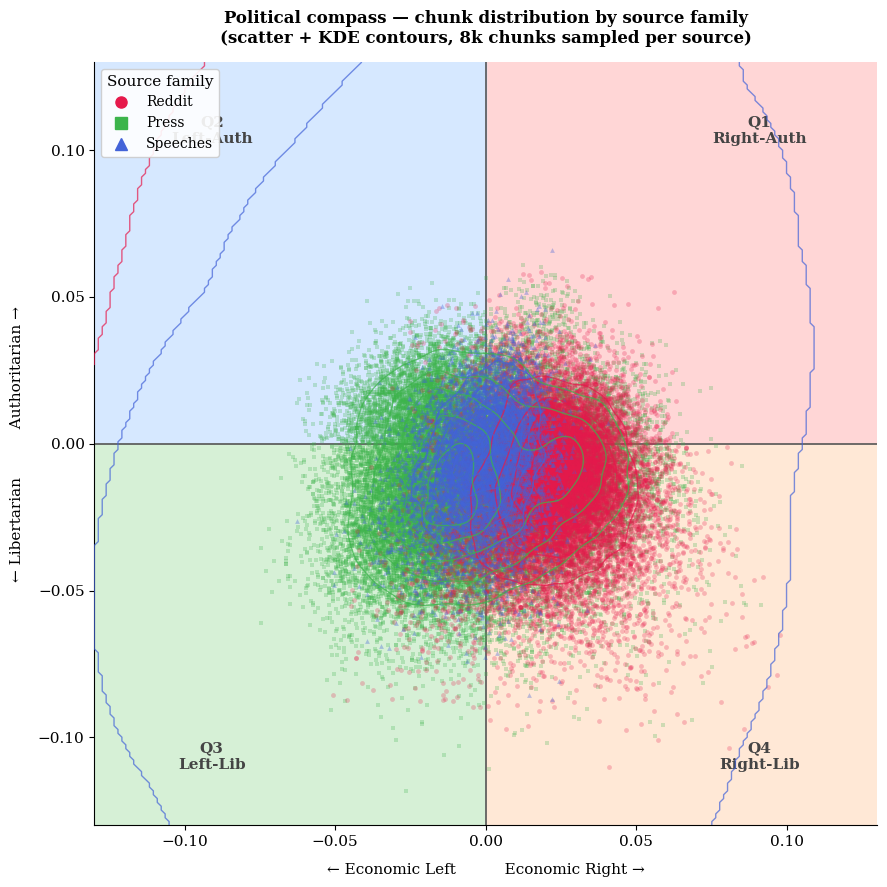

In [6]:
lim = 0.13
fig, ax = plt.subplots(figsize=(9, 9))

ax.axhspan( 0,    lim,  xmin=0.5, xmax=1,   color="#ffd6d6", zorder=0)  # Q1
ax.axhspan( 0,    lim,  xmin=0,   xmax=0.5, color="#d6e8ff", zorder=0)  # Q2
ax.axhspan(-lim,  0,    xmin=0,   xmax=0.5, color="#d6f0d6", zorder=0)  # Q3
ax.axhspan(-lim,  0,    xmin=0.5, xmax=1,   color="#ffe8d6", zorder=0)  # Q4
ax.axhline(0, color="#555", lw=1.2, zorder=1)
ax.axvline(0, color="#555", lw=1.2, zorder=1)

for fam, style in FAMILY_STYLE.items():
    pts = compass_points[fam]
    ax.scatter(pts["econ"], pts["soc"],
               c=style["color"], marker=style["marker"],
               alpha=style["alpha"], s=12, linewidths=0, zorder=style["zorder"])

grid_x = np.linspace(-lim, lim, 200)
grid_y = np.linspace(-lim, lim, 200)
xx, yy = np.meshgrid(grid_x, grid_y)
grid_coords = np.vstack([xx.ravel(), yy.ravel()])

for fam, style in FAMILY_STYLE.items():
    pts = compass_points[fam]
    if len(pts["econ"]) < 100:
        continue
    kde = gaussian_kde(np.vstack([pts["econ"], pts["soc"]]), bw_method=0.15)
    zz  = kde(grid_coords).reshape(xx.shape)
    ax.contour(xx, yy, zz, levels=5, colors=style["color"], linewidths=1.0, alpha=0.7, zorder=5)

kw = dict(fontsize=11, fontweight="bold", color="#444", va="center", ha="center")
ax.text( lim * 0.7,  lim * 0.82, "Q1\nRight-Auth", **kw)
ax.text(-lim * 0.7,  lim * 0.82, "Q2\nLeft-Auth",  **kw)
ax.text(-lim * 0.7, -lim * 0.82, "Q3\nLeft-Lib",   **kw)
ax.text( lim * 0.7, -lim * 0.82, "Q4\nRight-Lib",  **kw)

ax.set_xlabel("← Economic Left          Economic Right →", fontsize=11, labelpad=10)
ax.set_ylabel("← Libertarian          Authoritarian →",   fontsize=11, labelpad=10)
ax.set_xlim(-lim, lim)
ax.set_ylim(-lim, lim)

handles = [
    mlines.Line2D([], [], color=st["color"], marker=st["marker"],
                  linestyle="None", markersize=8, label=fam)
    for fam, st in FAMILY_STYLE.items()
]
ax.legend(handles=handles, title="Source family", fontsize=10, loc="upper left", framealpha=0.9)
ax.set_title(
    "Political compass — chunk distribution by source family\n"
    "(scatter + KDE contours, 8k chunks sampled per source)",
    fontsize=12, fontweight="bold", pad=14,
)
plt.tight_layout()
plt.savefig("../data/experts/quadrant-pools/political_compass.png", dpi=150, bbox_inches="tight")
plt.show()

# Phase A — Manual analysis

**Goal:** decide the viable topic set, the target N per quadrant, and the source cap.

**Inputs:** `retained.jsonl` in `quadrant-pools/<source>/<quadrant>/`, filtered at `conf_margin ≥ 0.015`, with `topic_primary` labels.

**Decisions to make:**
1. Which topics are well-represented across all four quadrants?
2. Which sources dominate individual cells → need capping or oversampling?
3. What is the confidence margin profile per cell?
4. Qualitative sanity-check: do retained texts actually sound like the intended quadrant?

In [7]:
TOPICS = [
    "economy", "immigration", "foreign_policy", "law_order",
    "environment_energy", "culture_identity", "welfare_labor",
    "health_education", "governance_institutions",
]
Q_ORDER = ["right_auth", "left_auth", "left_lib", "right_lib"]
Q_SHORT2 = {"right_auth": "Q1\nright_auth", "left_auth": "Q2\nleft_auth",
            "left_lib": "Q3\nleft_lib",     "right_lib": "Q4\nright_lib"}
SOURCES_LIST = SOURCES
SOURCE_COLORS = ["#e6194b", "#3cb44b", "#4363d8", "#f58231", "#911eb4", "#42d4f4", "#f032e6"]

rows = []
for source in SOURCES:
    for quadrant in QUADRANTS:
        path = BASE / source / quadrant / "retained.jsonl"
        if not path.exists():
            continue
        with open(path) as f:
            for line in f:
                d = json.loads(line)
                rows.append({
                    "source":            source,
                    "quadrant":          quadrant,
                    "topic_primary":     d.get("topic_primary"),
                    "confidence_margin": d.get("confidence_margin"),
                    "score_econ":        d.get("score_econ"),
                    "score_soc":         d.get("score_soc"),
                    "text":              d.get("text", ""),
                })

df_ret = pd.DataFrame(rows)
print(f"Total retained: {len(df_ret):,}")
print(f"topic_primary null rate: {df_ret['topic_primary'].isna().mean():.1%}")
print()
print(df_ret.groupby(["quadrant", "source"]).size().unstack(fill_value=0)[SOURCES])

Total retained: 374,495
topic_primary null rate: 0.0%

source      allsides  ec_press  ire_press  uk_press    hoc  reddit_liberal  \
quadrant                                                                     
left_auth         12      7850        281      1386    554             150   
left_lib          61     17342       2906     23311  13547            1831   
right_auth      1073        16         40      4415   1956            3553   
right_lib       5314       120        247      9529   2936           28341   

source      reddit_conservative  
quadrant                         
left_auth                   493  
left_lib                   3104  
right_auth                36371  
right_lib                207756  


## A.1 — Topic × quadrant count matrix

Rows = topics, columns = quadrants. Cell = retained chunk count. Log-scale colour; annotated with raw counts.
Flag cells < 500 chunks as underrepresented.

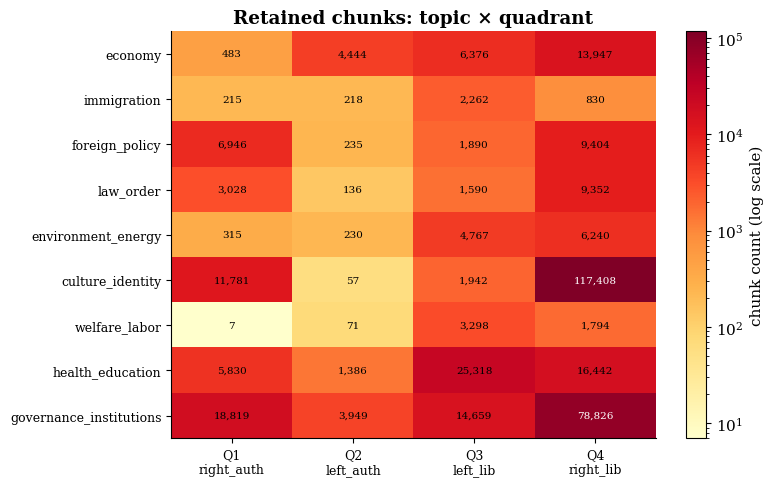

Underrepresented cells (< 500 chunks):
  economy × right_auth: 483
  immigration × right_auth: 215
  immigration × left_auth: 218
  foreign_policy × left_auth: 235
  law_order × left_auth: 136
  environment_energy × right_auth: 315
  environment_energy × left_auth: 230
  culture_identity × left_auth: 57
  welfare_labor × right_auth: 7
  welfare_labor × left_auth: 71


In [8]:
import matplotlib.colors as mcolors

pivot = (
    df_ret.groupby(["topic_primary", "quadrant"])
    .size()
    .unstack(fill_value=0)
    .reindex(index=TOPICS, columns=Q_ORDER, fill_value=0)
)
mat = pivot.values.astype(float)
mat_plot = np.where(mat == 0, np.nan, mat)

fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(
    mat_plot,
    norm=mcolors.LogNorm(vmin=max(1, np.nanmin(mat_plot)), vmax=np.nanmax(mat_plot)),
    cmap="YlOrRd", aspect="auto",
)
for i in range(len(TOPICS)):
    for j in range(len(Q_ORDER)):
        v = int(mat[i, j])
        ax.text(j, i, f"{v:,}", ha="center", va="center", fontsize=7.5,
                color="white" if v > np.nanmax(mat_plot) * 0.4 else "black")
ax.set_xticks(range(len(Q_ORDER)))
ax.set_xticklabels([Q_SHORT2[q] for q in Q_ORDER], fontsize=9)
ax.set_yticks(range(len(TOPICS)))
ax.set_yticklabels(TOPICS, fontsize=9)
plt.colorbar(im, ax=ax, label="chunk count (log scale)")
ax.set_title("Retained chunks: topic × quadrant", fontweight="bold")
plt.tight_layout()
plt.show()

print("Underrepresented cells (< 500 chunks):")
for i, t in enumerate(TOPICS):
    for j, q in enumerate(Q_ORDER):
        if mat[i, j] < 500:
            print(f"  {t} × {q}: {int(mat[i,j])}")

## A.2 — Source dominance per (topic × quadrant) cell

Stacked bar: source share per quadrant. Cells where one source > 80% are flagged — risk of encoding source style rather than ideology.

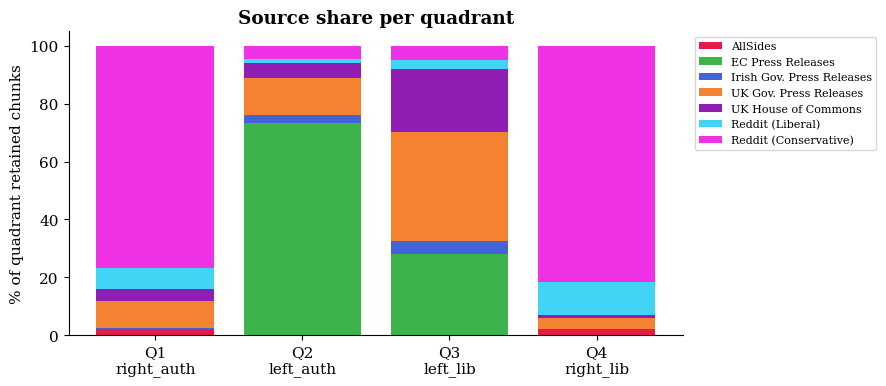


Flagged cells (one source > 80% per topic × quadrant):
          topic_primary   quadrant              source        pct
       culture_identity right_auth reddit_conservative  86.546134
       culture_identity  right_lib reddit_conservative  89.096995
                economy  left_auth            ec_press  95.747075
governance_institutions right_auth reddit_conservative  82.560179
governance_institutions  right_lib reddit_conservative  80.278081
            immigration  right_lib reddit_conservative  80.481928
              law_order right_auth reddit_conservative  84.445178
              law_order  right_lib reddit_conservative  84.698460
          welfare_labor right_auth reddit_conservative 100.000000


In [9]:
grp = df_ret.groupby(["topic_primary", "quadrant", "source"]).size().reset_index(name="n")
total = grp.groupby(["topic_primary", "quadrant"])["n"].transform("sum")
grp["pct"] = grp["n"] / total * 100

# Per-quadrant source share (aggregated over topics)
q_grp = df_ret.groupby(["quadrant", "source"]).size().unstack(fill_value=0)
q_grp = q_grp.reindex(index=Q_ORDER, columns=SOURCES_LIST, fill_value=0)
q_pct = q_grp.div(q_grp.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(9, 4))
bottom = np.zeros(len(Q_ORDER))
for src, color in zip(SOURCES_LIST, SOURCE_COLORS):
    vals = q_pct[src].values if src in q_pct.columns else np.zeros(len(Q_ORDER))
    ax.bar([Q_SHORT2[q] for q in Q_ORDER], vals, bottom=bottom, label=SOURCE_LABEL[src], color=color)
    bottom += vals
ax.set_ylabel("% of quadrant retained chunks")
ax.set_title("Source share per quadrant", fontweight="bold")
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

print("\nFlagged cells (one source > 80% per topic × quadrant):")
dominant = grp.loc[grp.groupby(["topic_primary", "quadrant"])["pct"].idxmax()]
flagged  = dominant[dominant["pct"] > 80]
print(flagged[["topic_primary", "quadrant", "source", "pct"]].to_string(index=False))

## A.3 — Confidence margin per (topic × quadrant) cell

Mean and median `conf_margin`. Darker blue = higher confidence. Low-confidence cells may warrant a higher per-cell floor.

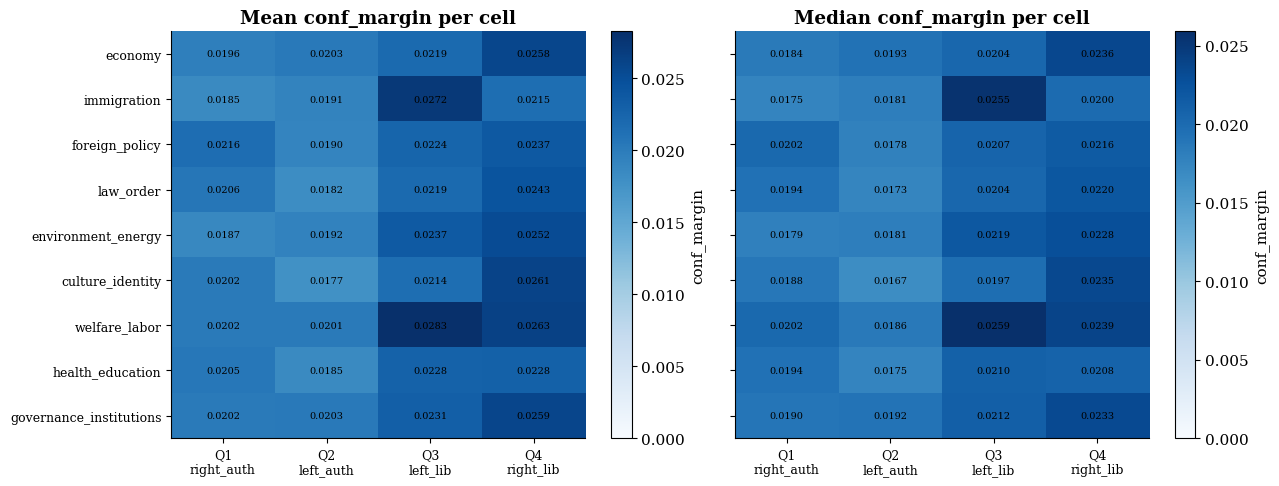

In [10]:
pivot_mean = (
    df_ret.groupby(["topic_primary", "quadrant"])["confidence_margin"]
    .mean().unstack(fill_value=0)
    .reindex(index=TOPICS, columns=Q_ORDER, fill_value=0)
)
pivot_med = (
    df_ret.groupby(["topic_primary", "quadrant"])["confidence_margin"]
    .median().unstack(fill_value=0)
    .reindex(index=TOPICS, columns=Q_ORDER, fill_value=0)
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
for ax, piv, title in zip(axes, [pivot_mean, pivot_med], ["Mean", "Median"]):
    mat = piv.values
    im = ax.imshow(mat, cmap="Blues", vmin=0, vmax=mat.max(), aspect="auto")
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            ax.text(j, i, f"{mat[i,j]:.4f}", ha="center", va="center", fontsize=7)
    ax.set_xticks(range(len(Q_ORDER)))
    ax.set_xticklabels([Q_SHORT2[q] for q in Q_ORDER], fontsize=9)
    ax.set_yticks(range(len(TOPICS)))
    ax.set_yticklabels(TOPICS, fontsize=9)
    plt.colorbar(im, ax=ax, label="conf_margin")
    ax.set_title(f"{title} conf_margin per cell", fontweight="bold")
plt.tight_layout()
plt.show()

## A.4 — Sample inspection

Set `INSPECT_TOPIC` and `INSPECT_QUADRANT` to read random retained chunks from that cell.
Sanity-check: does the text belong in this quadrant? Any false positives, boilerplate, or non-English?

In [11]:
INSPECT_TOPIC    = "economy"       # set to None to skip topic filter
INSPECT_QUADRANT = "right_auth"    # right_auth | left_auth | left_lib | right_lib
N_SAMPLES        = 5

mask = df_ret["quadrant"] == INSPECT_QUADRANT
if INSPECT_TOPIC is not None:
    mask &= df_ret["topic_primary"] == INSPECT_TOPIC

pool  = df_ret[mask].reset_index(drop=True)
label = f"{INSPECT_TOPIC} × {INSPECT_QUADRANT}" if INSPECT_TOPIC else INSPECT_QUADRANT
print(f"Cell: {label}  |  retained: {len(pool):,}")
print("=" * 72)

for i, idx in enumerate(random.sample(range(len(pool)), min(N_SAMPLES, len(pool))), 1):
    row = pool.iloc[idx]
    print(f"\n--- {i} | source={row.source} | conf={row.confidence_margin:.4f}")
    print(row["text"][:600])

Cell: economy × right_auth  |  retained: 483

--- 1 | source=hoc | conf=0.0164
I am grateful to my hon. Friend. It is certainly true that the Spey engines have proved an outstanding success. The Royal Navy has great confidence in them and they were chosen for their quality, flexibility and efficiency. They have stood the Royal Navy in good stead. It is because of our defence programme's ability to maintain an effective ordering programme that we can also attract interest among overseas countries. What we invest in is always of great interest to such countries. They know that if an item has the Royal Navy's endorsement it is bound to be of good quality.

--- 2 | source=reddit_conservative | conf=0.0251
instances, the cost of carrying on the usual business of the United States was $2,187,000,000 in 1927, $3,168,000,000 in 1931 -- an increase in four years of one billion dollars! Incredible, isn't it? But that isn't the half of it, he told his audience. Not by a long shot. There is someth